In [ ]:
# =========================================================
# INSTALL DEPENDENCIES
# =========================================================
!pip install -q seaborn opencv-python pillow tqdm
# =========================================================
# IMPORTS
# =========================================================
import os
import cv2
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance
from tqdm.auto import tqdm
import time
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

warnings.filterwarnings("ignore")

In [ ]:
# =========================================================
# MOUNT GOOGLE DRIVE
# =========================================================
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================================================
# REPRODUCIBILITY
# =========================================================
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

📊 DATASET STATISTICS:
Total samples: 3120
Unique classes: 15
Samples per class (min/avg/max): 40/208.0/400


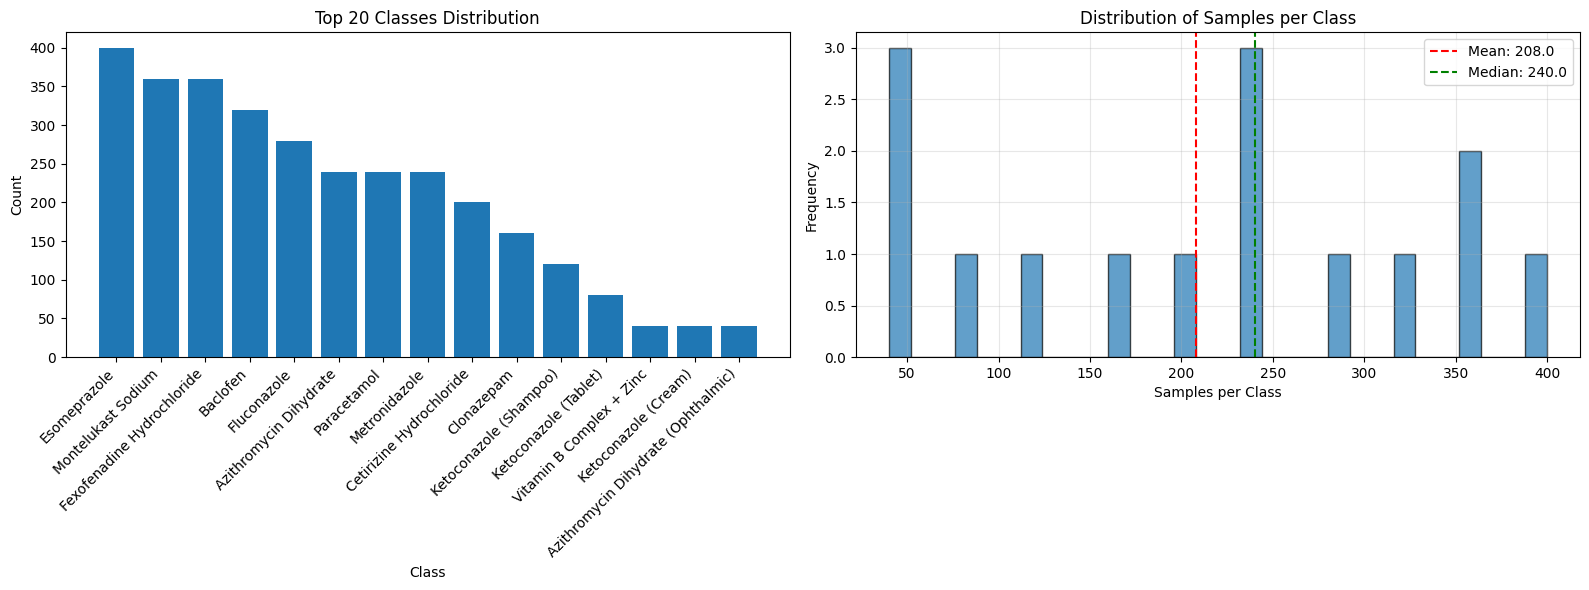

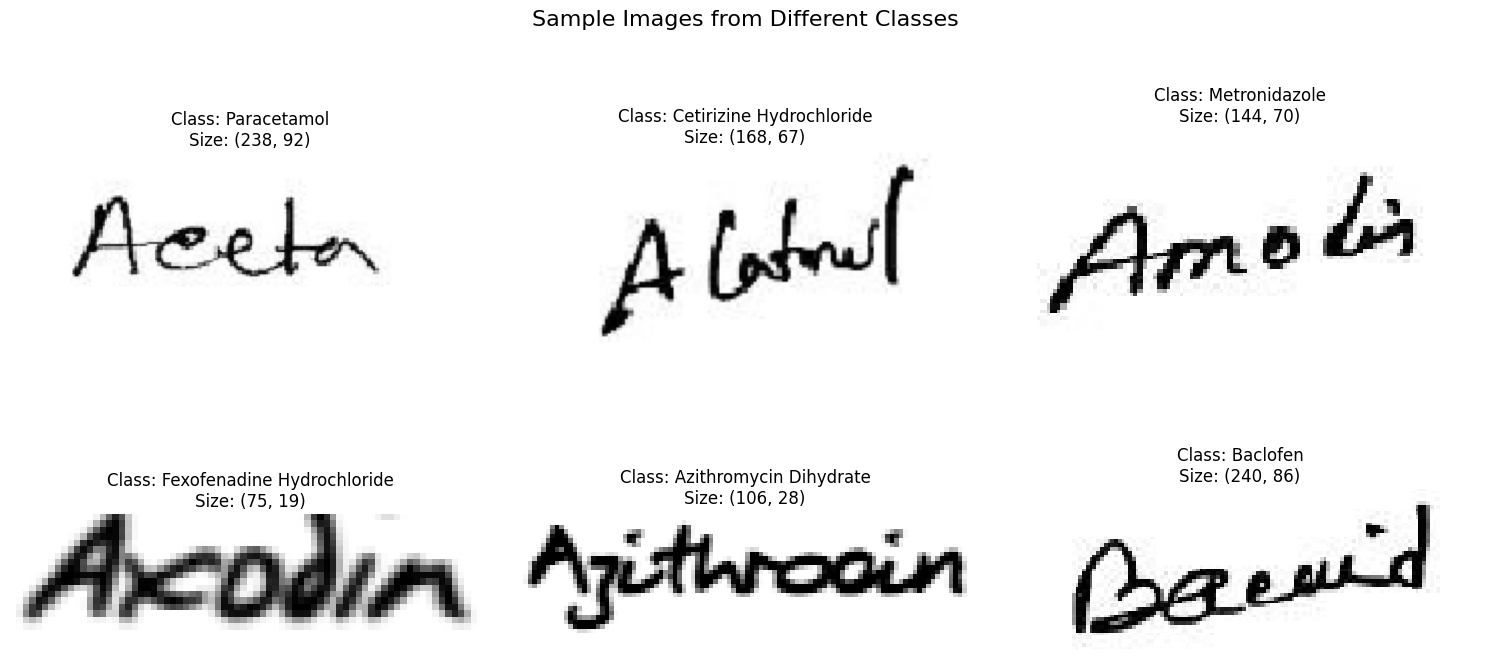

In [ ]:
# =========================================================
# EXPLORATORY DATA ANALYSIS
# =========================================================
ROOT = "/content/drive/MyDrive/CSE427/project/Doctor-s-Handwritten-Prescription-main/Training"
LABELS = os.path.join(ROOT, "training_labels.csv")

# Load dataset
df = pd.read_csv(LABELS)
df["image_path"] = df["IMAGE"].apply(
    lambda x: os.path.join(ROOT, "training_words", x)
)

# Filter only existing files
df = df[df["image_path"].apply(os.path.exists)]

print("📊 DATASET STATISTICS:")
print("="*50)
print(f"Total samples: {len(df)}")
print(f"Unique classes: {df['GENERIC_NAME'].nunique()}")
print(f"Samples per class (min/avg/max): {df['GENERIC_NAME'].value_counts().min():.0f}/"
      f"{df['GENERIC_NAME'].value_counts().mean():.1f}/"
      f"{df['GENERIC_NAME'].value_counts().max():.0f}")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 classes
top_classes = df["GENERIC_NAME"].value_counts().head(20)
axes[0].bar(range(len(top_classes)), top_classes.values)
axes[0].set_xticks(range(len(top_classes)))
axes[0].set_xticklabels(top_classes.index, rotation=45, ha='right')
axes[0].set_title('Top 20 Classes Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

# All classes histogram
class_counts = df["GENERIC_NAME"].value_counts()
axes[1].hist(class_counts.values, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(class_counts.mean(), color='red', linestyle='--',
               label=f'Mean: {class_counts.mean():.1f}')
axes[1].axvline(class_counts.median(), color='green', linestyle='--',
               label=f'Median: {class_counts.median():.1f}')
axes[1].set_title('Distribution of Samples per Class')
axes[1].set_xlabel('Samples per Class')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show sample images
plt.figure(figsize=(15, 8))
unique_classes = df["GENERIC_NAME"].unique()[:6]

for i, class_name in enumerate(unique_classes):
    class_samples = df[df["GENERIC_NAME"] == class_name]

    if len(class_samples) > 0:
        sample_path = class_samples.iloc[0]["image_path"]
        img = Image.open(sample_path).convert("L")

        plt.subplot(2, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'Class: {class_name}\nSize: {img.size}')
        plt.axis('off')

plt.suptitle('Sample Images from Different Classes', fontsize=16)
plt.tight_layout()
plt.show()

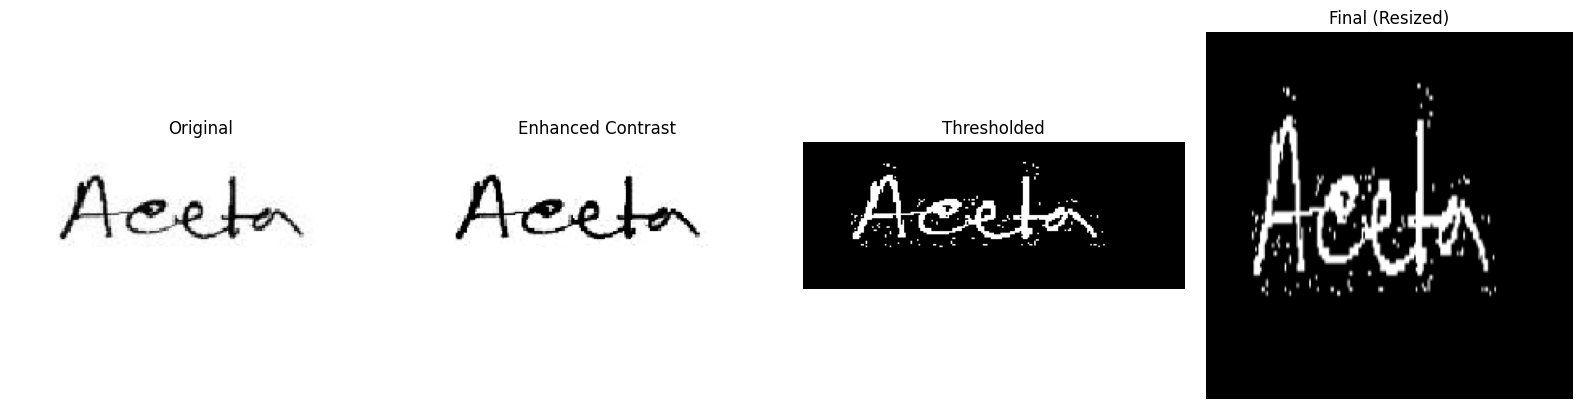

In [ ]:
# =========================================================
# DATA PREPROCESSING FUNCTIONS
# =========================================================
class ImagePreprocessor:
    @staticmethod
    def preprocess(path, size=(224, 224), enhance_contrast=True):
        """Preprocess image: convert to grayscale, enhance contrast, threshold, resize"""
        try:
            # Load image
            img = Image.open(path).convert("L")

            # Enhance contrast
            if enhance_contrast:
                img = ImageEnhance.Contrast(img).enhance(2.0)

            # Adaptive thresholding
            img_np = np.array(img)
            img_thresh = cv2.adaptiveThreshold(
                img_np, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY_INV, 11, 2
            )

            # Convert back to PIL and resize
            img = Image.fromarray(img_thresh).convert("RGB")
            img = img.resize(size, Image.Resampling.LANCZOS)

            return img

        except Exception as e:
            print(f"Error preprocessing {path}: {e}")
            # Return blank image if error
            return Image.new('RGB', size, color='white')

    @staticmethod
    def visualize_preprocessing(path):
        """Visualize preprocessing steps"""
        original = Image.open(path).convert("L")

        # Apply preprocessing steps
        enhanced = ImageEnhance.Contrast(original).enhance(2.0)
        enhanced_np = np.array(enhanced)
        thresholded = cv2.adaptiveThreshold(
            enhanced_np, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 11, 2
        )
        final = Image.fromarray(thresholded).convert("RGB").resize((224, 224))

        # Plot
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        images = [original, enhanced, Image.fromarray(thresholded), final]
        titles = ['Original', 'Enhanced Contrast', 'Thresholded', 'Final (Resized)']

        for ax, img, title in zip(axes, images, titles):
            ax.imshow(img, cmap='gray' if title != 'Final (Resized)' else None)
            ax.set_title(title)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

# Visualize preprocessing
if len(df) > 0:
    sample_path = df.iloc[0]["image_path"]
    ImagePreprocessor.visualize_preprocessing(sample_path)

In [ ]:
# =========================================================
# DATASET CLASS
# =========================================================
class PrescriptionDataset(Dataset):
    def __init__(self, df, transform=None, preprocess=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.preprocess = preprocess

        # Create label mapping
        self.classes = sorted(df["GENERIC_NAME"].unique())
        self.label_map = {label: idx for idx, label in enumerate(self.classes)}
        self.reverse_map = {idx: label for label, idx in self.label_map.items()}

        print(f"Dataset initialized with {len(self)} samples and {len(self.classes)} classes")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            # Get image path and label
            img_path = self.df.loc[idx, "image_path"]
            label = self.label_map[self.df.loc[idx, "GENERIC_NAME"]]

            # Preprocess image
            if self.preprocess:
                img = ImagePreprocessor.preprocess(img_path)
            else:
                img = Image.open(img_path).convert("RGB")
                img = img.resize((224, 224))

            # Apply transforms
            if self.transform:
                img = self.transform(img)

            return img, label

        except Exception as e:
            print(f"Error loading sample {idx}: {e}")
            # Return a dummy sample
            dummy_img = torch.zeros((3, 224, 224))
            return dummy_img, 0

📈 AFTER FILTERING (min_samples=10):
  Samples: 3120
  Classes: 15
  Samples per class (min/avg/max): 40/208.0/400

🔀 DATA SPLITTING:
  Train set: 2184 samples
  Validation set: 468 samples
  Test set: 468 samples


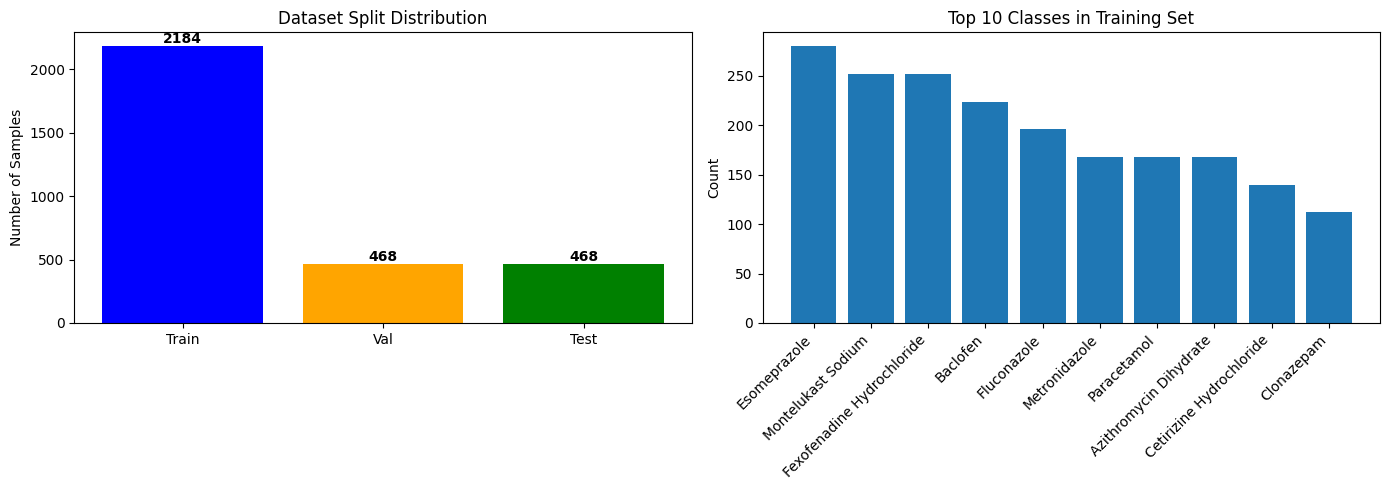

In [ ]:
# =========================================================
# DATA PREPARATION AND SPLITTING
# =========================================================
# Filter classes with minimum samples
MIN_SAMPLES_PER_CLASS = 10
class_counts = df["GENERIC_NAME"].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index
df_filtered = df[df["GENERIC_NAME"].isin(valid_classes)]

print(f"📈 AFTER FILTERING (min_samples={MIN_SAMPLES_PER_CLASS}):")
print(f"  Samples: {len(df_filtered)}")
print(f"  Classes: {df_filtered['GENERIC_NAME'].nunique()}")
print(f"  Samples per class (min/avg/max): {df_filtered['GENERIC_NAME'].value_counts().min():.0f}/"
      f"{df_filtered['GENERIC_NAME'].value_counts().mean():.1f}/"
      f"{df_filtered['GENERIC_NAME'].value_counts().max():.0f}")

# Stratified split
train_df, temp_df = train_test_split(
    df_filtered, test_size=0.3,
    stratify=df_filtered["GENERIC_NAME"],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5,
    stratify=temp_df["GENERIC_NAME"],
    random_state=42
)

print(f"\n🔀 DATA SPLITTING:")
print(f"  Train set: {len(train_df)} samples")
print(f"  Validation set: {len(val_df)} samples")
print(f"  Test set: {len(test_df)} samples")

# Plot split distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split sizes
split_counts = {"Train": len(train_df), "Val": len(val_df), "Test": len(test_df)}
axes[0].bar(split_counts.keys(), split_counts.values(), color=['blue', 'orange', 'green'])
axes[0].set_title("Dataset Split Distribution")
axes[0].set_ylabel("Number of Samples")
for i, (name, count) in enumerate(split_counts.items()):
    axes[0].text(i, count + max(split_counts.values())*0.01, str(count),
                ha='center', fontweight='bold')

# Class distribution in splits
train_class_counts = train_df["GENERIC_NAME"].value_counts().head(10)
axes[1].bar(range(len(train_class_counts)), train_class_counts.values)
axes[1].set_xticks(range(len(train_class_counts)))
axes[1].set_xticklabels(train_class_counts.index, rotation=45, ha='right')
axes[1].set_title("Top 10 Classes in Training Set")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# DATA TRANSFORMS AND LOADERS
# =========================================================
# Data transforms with augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = PrescriptionDataset(train_df, transform=train_transform)
val_dataset = PrescriptionDataset(val_df, transform=val_test_transform)
test_dataset = PrescriptionDataset(test_df, transform=val_test_transform)

# Create data loaders
BATCH_SIZE = 32
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True,
    persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True,
    persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True,
    persistent_workers=True
)

print(f"📦 DATA LOADERS CREATED:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Dataset initialized with 2184 samples and 15 classes
Dataset initialized with 468 samples and 15 classes
Dataset initialized with 468 samples and 15 classes
📦 DATA LOADERS CREATED:
  Train batches: 69
  Val batches: 15
  Test batches: 15


In [ ]:
# =========================================================
# TRAINING UTILITIES AND EARLY STOPPING
# =========================================================
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_state = model.state_dict().copy()
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_state = model.state_dict().copy()
            self.counter = 0

        return self.early_stop

class Trainer:
    def __init__(self, model, device, model_name="", early_stopping_patience=15):
        self.model = model
        self.device = device
        self.model_name = model_name
        self.early_stopping = EarlyStopping(patience=early_stopping_patience, verbose=True)
        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': []
        }

    def train_epoch(self, train_loader, criterion, optimizer, epoch, total_epochs):
        """Train for one epoch"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{total_epochs}',
                   leave=False, dynamic_ncols=True)

        for batch_idx, (inputs, targets) in enumerate(pbar):
            inputs, targets = inputs.to(self.device), targets.to(self.device)

            # Forward pass
            optimizer.zero_grad(set_to_none=True)
            outputs = self.model(inputs)
            loss = criterion(outputs, targets)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            # Update progress bar
            current_loss = running_loss / (batch_idx + 1)
            current_acc = 100. * correct / total
            pbar.set_postfix({
                'Loss': f'{current_loss:.3f}',
                'Acc': f'{current_acc:.2f}%'
            })

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total

        self.history['train_loss'].append(epoch_loss)
        self.history['train_acc'].append(epoch_acc)

        return epoch_loss, epoch_acc

    def validate(self, val_loader, criterion):
        """Validate model"""
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                loss = criterion(outputs, targets)

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        val_loss = running_loss / len(val_loader)
        val_acc = 100. * correct / total

        self.history['val_loss'].append(val_loss)
        self.history['val_acc'].append(val_acc)

        return val_loss, val_acc

    def plot_training_history(self):
        """Plot training history"""
        if len(self.history['train_loss']) == 0:
            print("No training history to plot")
            return

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        epochs = range(1, len(self.history['train_loss']) + 1)

        # Loss plot
        axes[0].plot(epochs, self.history['train_loss'], 'b-', label='Train Loss', linewidth=2)
        axes[0].plot(epochs, self.history['val_loss'], 'r-', label='Val Loss', linewidth=2)
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy plot
        axes[1].plot(epochs, self.history['train_acc'], 'b-', label='Train Acc', linewidth=2)
        axes[1].plot(epochs, self.history['val_acc'], 'r-', label='Val Acc', linewidth=2)
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].set_title('Training and Validation Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.suptitle(f'Training History - {self.model_name}', fontsize=14)
        plt.tight_layout()
        plt.show()

In [ ]:
# =========================================================
# EVALUATION FUNCTIONS
# =========================================================
def evaluate_model_comprehensive(model, loader, device, class_names):
    """Comprehensive model evaluation"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted'
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': np.array(all_probs)
    }

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    """Plot confusion matrix"""
    plt.figure(figsize=(10, 8))

    # Only show top classes if too many
    if len(class_names) > 20:
        display_classes = 20
        cm_display = cm[:display_classes, :display_classes]
        class_names_display = class_names[:display_classes]
        title += " (Top 20 Classes)"
    else:
        cm_display = cm
        class_names_display = class_names
        display_classes = len(class_names)

    sns.heatmap(cm_display, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_display,
                yticklabels=class_names_display)

    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
# =========================================================
# HYBRID MODEL (CNN + Transformer)
# =========================================================
class CNNTransformerHybrid(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3):
        super().__init__()

        # CNN Backbone (ResNet18) - pretrained
        backbone = models.resnet18(weights="IMAGENET1K_V1")

        # Remove final layers
        self.cnn = nn.Sequential(*list(backbone.children())[:-2])

        # Adaptive pooling
        self.pool = nn.AdaptiveAvgPool2d((7, 7))

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=512, nhead=8, dim_feedforward=2048,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Fully connected layers
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # CNN feature extraction
        x = self.cnn(x)
        x = self.pool(x)

        # Reshape for transformer
        x = x.flatten(2).permute(0, 2, 1)  # [batch, seq_len, features]

        # Transformer encoding
        x = self.transformer(x)

        # Global pooling
        x = x.mean(dim=1)

        # Fully connected layers
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
# =========================================================
# MODEL MODIFICATION FUNCTIONS
# =========================================================
def modify_vit(model, num_classes):
    """Modify Vision Transformer classifier"""
    # Freeze backbone initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze classifier and last few layers
    for param in model.heads.parameters():
        param.requires_grad = True

    # Also unfreeze last transformer blocks for fine-tuning
    for param in model.encoder.layers[-2:].parameters():
        param.requires_grad = True

    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model

def modify_hybrid(model, num_classes):
    """Hybrid model - freeze CNN backbone, train transformer and FC layers"""
    # CNN backbone is already frozen in the model definition
    # Make sure transformer and FC layers are trainable
    for name, param in model.named_parameters():
        if 'cnn' in name:
            param.requires_grad = False
        else:
            param.requires_grad = True
    return model

def modify_efficientnet(model, num_classes):
    """Modify EfficientNet classifier"""
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model

def modify_densenet(model, num_classes):
    """Modify DenseNet classifier"""
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

def modify_mobilenet(model, num_classes):
    """Modify MobileNetV3 classifier"""
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 1280),
        nn.Hardswish(inplace=True),
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(1280, num_classes)
    )
    return model

def modify_resnet(model, num_classes):
    """Modify ResNet classifier"""
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

In [ ]:
# =========================================================
# TRAINING FUNCTION
# =========================================================
def train_and_evaluate_model(model, model_name, train_loader, val_loader, test_loader,
                           device, num_classes, class_names, epochs=100, lr=1e-4):
    """Complete training and evaluation for a single model with early stopping"""
    print(f"\n{'='*60}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*60}")

    start_time = time.time()

    # Create trainer with early stopping
    trainer = Trainer(model, device, model_name, early_stopping_patience=5)

    # Define loss and optimizer
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Optimizer with gradient clipping for stability
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=0.01
    )

    # Learning rate scheduler with cosine annealing
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    # Training loop with early stopping
    best_val_acc = 0
    best_epoch = 0
    early_stop_triggered = False

    print(f"\nStarting training for {epochs} epochs (early stopping patience: 5)...")

    for epoch in range(epochs):
        # Train
        train_loss, train_acc = trainer.train_epoch(
            train_loader, criterion, optimizer, epoch, epochs
        )

        # Validate
        val_loss, val_acc = trainer.validate(val_loader, criterion)

        # Update learning rate
        scheduler.step()

        print(f"\nEpoch {epoch+1}/{epochs} Summary:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.2e}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f"best_{model_name.replace(' ', '_')}.pth")
            print(f"  💾 Saved best model (Epoch {best_epoch}) with val_acc: {val_acc:.2f}%")

        # Check early stopping
        if trainer.early_stopping(val_loss, model):
            print(f"⏹️  Early stopping triggered at epoch {epoch+1}")
            early_stop_triggered = True
            break

        # Clear cache periodically
        if torch.cuda.is_available() and (epoch + 1) % 10 == 0:
            torch.cuda.empty_cache()

    # Load best model
    if early_stop_triggered and trainer.early_stopping.best_state is not None:
        model.load_state_dict(trainer.early_stopping.best_state)
        print(f"Loaded best model from early stopping (epoch {best_epoch})")
    else:
        try:
            model.load_state_dict(torch.load(f"best_{model_name.replace(' ', '_')}.pth", map_location=device))
            print(f"Loaded best model from epoch {best_epoch}")
        except:
            print("Using final model for evaluation")

    # Plot training history
    trainer.plot_training_history()

    # Evaluate on test set
    print("\n📊 Evaluating on test set...")
    test_metrics = evaluate_model_comprehensive(
        model, test_loader, device, class_names
    )

    # Calculate training time
    training_time = time.time() - start_time

    # Print results
    print(f"\n✅ {model_name} Results:")
    print(f"   Test Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"   Test Precision: {test_metrics['precision']:.4f}")
    print(f"   Test Recall: {test_metrics['recall']:.4f}")
    print(f"   Test F1-Score: {test_metrics['f1_score']:.4f}")
    print(f"   Training Time: {training_time/60:.2f} minutes")
    print(f"   Best Validation Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")
    print(f"   Total Epochs Trained: {len(trainer.history['train_loss'])}")

    # Plot confusion matrix
    plot_confusion_matrix(
        test_metrics['confusion_matrix'],
        class_names,
        title=f"Confusion Matrix - {model_name}"
    )

    return {
        'Model': model_name,
        'Accuracy': test_metrics['accuracy'],
        'Precision': test_metrics['precision'],
        'Recall': test_metrics['recall'],
        'F1-score': test_metrics['f1_score'],
        'Training Time (min)': training_time / 60,
        'Best Val Acc (%)': best_val_acc,
        'Best Epoch': best_epoch,
        'Total Epochs': len(trainer.history['train_loss'])
    }

In [ ]:
# =========================================================
# SETUP DEVICE AND VARIABLES
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    # Set mixed precision for T4
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes
print(f"\nNumber of classes: {num_classes}")

# Initialize results list
all_results = []

Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB

Number of classes: 15



MODEL 1: EfficientNet-B3
Total parameters: 10,719,287
Trainable parameters: 23,055
Trainable percentage: 0.22%

TRAINING: EfficientNet-B3

Starting training for 100 epochs (early stopping patience: 5)...


Epoch 1/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 1/100 Summary:
  Train Loss: 2.6379, Train Acc: 10.81%
  Val Loss: 2.5885, Val Acc: 12.39%
  LR: 1.00e-04
  💾 Saved best model (Epoch 1) with val_acc: 12.39%


Epoch 2/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 2/100 Summary:
  Train Loss: 2.5615, Train Acc: 12.68%
  Val Loss: 2.5620, Val Acc: 15.17%
  LR: 9.99e-05
  💾 Saved best model (Epoch 2) with val_acc: 15.17%


...


Epoch 54/100 Summary:
  Train Loss: 2.2898, Train Acc: 27.98%
  Val Loss: 2.2939, Val Acc: 27.35%
  LR: 4.43e-05
EarlyStopping counter: 3 out of 5


Epoch 55/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 55/100 Summary:
  Train Loss: 2.2877, Train Acc: 29.17%
  Val Loss: 2.2919, Val Acc: 27.78%
  LR: 4.28e-05
EarlyStopping counter: 4 out of 5


Epoch 56/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 56/100 Summary:
  Train Loss: 2.2775, Train Acc: 30.77%
  Val Loss: 2.2902, Val Acc: 27.35%
  LR: 4.12e-05
EarlyStopping counter: 5 out of 5
⏹️  Early stopping triggered at epoch 56
Loaded best model from early stopping (epoch 48)


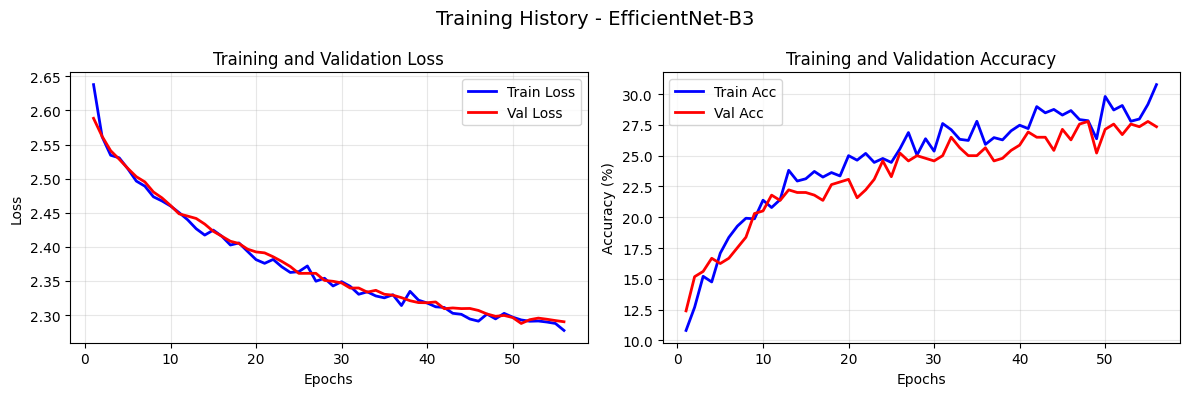


📊 Evaluating on test set...


Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]


✅ EfficientNet-B3 Results:
   Test Accuracy: 0.2970
   Test Precision: 0.3268
   Test Recall: 0.2970
   Test F1-Score: 0.2660
   Training Time: 27.53 minutes
   Best Validation Accuracy: 27.78% (Epoch 48)
   Total Epochs Trained: 56


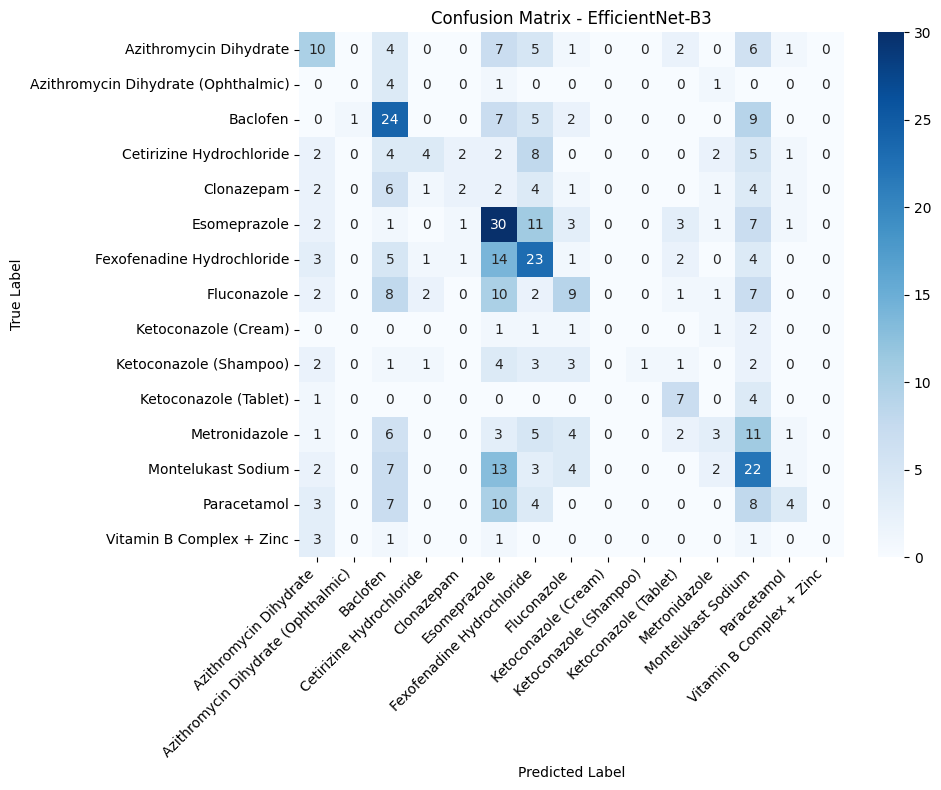

In [ ]:
# =========================================================
# MODEL 1: EfficientNet-B3
# =========================================================
print("\n" + "="*60)
print("MODEL 1: EfficientNet-B3")
print("="*60)

# Initialize model
model_effnet = models.efficientnet_b3(weights="IMAGENET1K_V1")
model_effnet = modify_efficientnet(model_effnet, num_classes)

# Freeze backbone, train only classifier
for param in model_effnet.parameters():
    param.requires_grad = False
for param in model_effnet.classifier.parameters():
    param.requires_grad = True

model_effnet = model_effnet.to(device)

# Count parameters
total_params = sum(p.numel() for p in model_effnet.parameters())
trainable_params = sum(p.numel() for p in model_effnet.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {trainable_params/total_params*100:.2f}%")

# Train and evaluate
effnet_results = train_and_evaluate_model(
    model=model_effnet,
    model_name="EfficientNet-B3",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    num_classes=num_classes,
    class_names=class_names,
    epochs=100,
    lr=1e-4
)

all_results.append(effnet_results)

# Clear GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


MODEL 2: DenseNet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 166MB/s]


Total parameters: 6,969,231
Trainable parameters: 15,375
Trainable percentage: 0.22%

TRAINING: DenseNet121

Starting training for 100 epochs (early stopping patience: 5)...


Epoch 1/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 1/100 Summary:
  Train Loss: 2.6162, Train Acc: 11.08%
  Val Loss: 2.5702, Val Acc: 12.18%
  LR: 1.00e-04
  💾 Saved best model (Epoch 1) with val_acc: 12.18%


...


Epoch 60/100 Summary:
  Train Loss: 2.0870, Train Acc: 38.28%
  Val Loss: 2.2085, Val Acc: 32.05%
  LR: 3.52e-05
EarlyStopping counter: 3 out of 5


Epoch 61/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 61/100 Summary:
  Train Loss: 2.0921, Train Acc: 37.68%
  Val Loss: 2.2047, Val Acc: 31.62%
  LR: 3.37e-05
EarlyStopping counter: 4 out of 5


Epoch 62/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 62/100 Summary:
  Train Loss: 2.0873, Train Acc: 37.91%
  Val Loss: 2.2095, Val Acc: 32.26%
  LR: 3.23e-05
EarlyStopping counter: 5 out of 5
⏹️  Early stopping triggered at epoch 62
Loaded best model from early stopping (epoch 50)


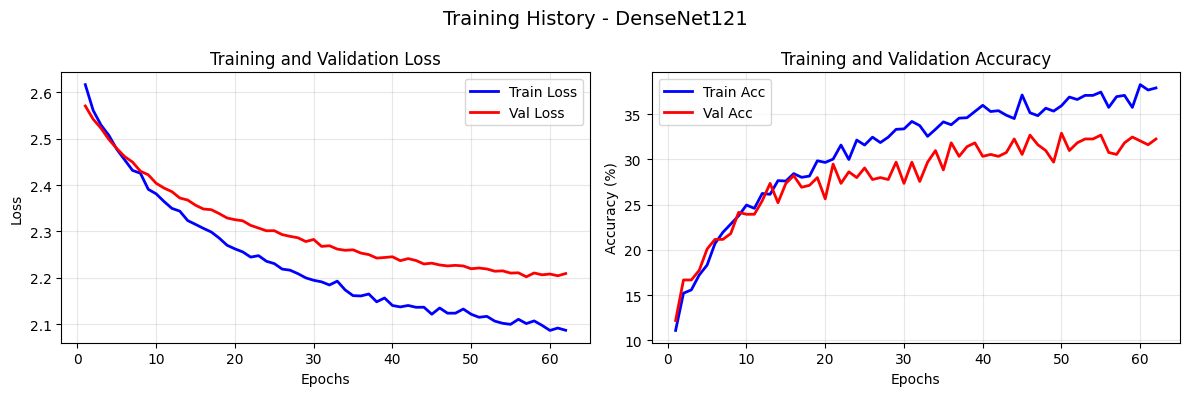


📊 Evaluating on test set...


Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]


✅ DenseNet121 Results:
   Test Accuracy: 0.3120
   Test Precision: 0.3060
   Test Recall: 0.3120
   Test F1-Score: 0.2912
   Training Time: 23.25 minutes
   Best Validation Accuracy: 32.91% (Epoch 50)
   Total Epochs Trained: 62


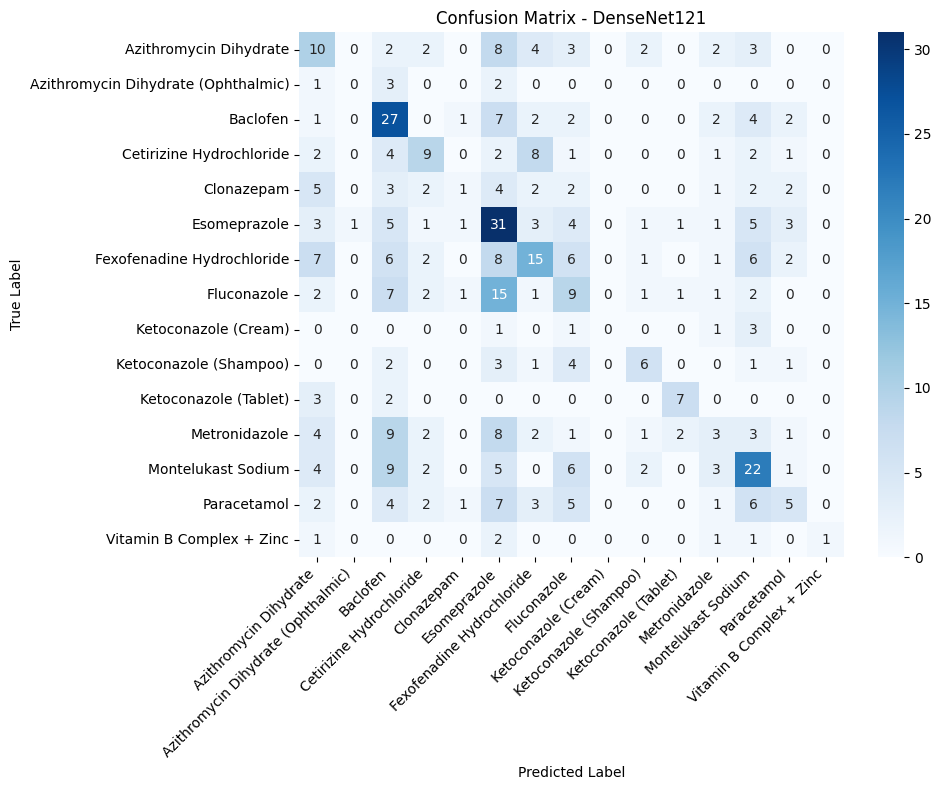

In [ ]:
# =========================================================
# MODEL 2: DenseNet121
# =========================================================
print("\n" + "="*60)
print("MODEL 2: DenseNet121")
print("="*60)

# Initialize model
model_densenet = models.densenet121(weights="IMAGENET1K_V1")
model_densenet = modify_densenet(model_densenet, num_classes)

# Freeze backbone, train only classifier
for param in model_densenet.parameters():
    param.requires_grad = False
for param in model_densenet.classifier.parameters():
    param.requires_grad = True

model_densenet = model_densenet.to(device)

# Count parameters
total_params = sum(p.numel() for p in model_densenet.parameters())
trainable_params = sum(p.numel() for p in model_densenet.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {trainable_params/total_params*100:.2f}%")

# Train and evaluate
densenet_results = train_and_evaluate_model(
    model=model_densenet,
    model_name="DenseNet121",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    num_classes=num_classes,
    class_names=class_names,
    epochs=100,
    lr=1e-4
)

all_results.append(densenet_results)

# Clear GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


MODEL 3: MobileNetV3-Large
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 156MB/s]


Total parameters: 4,221,247
Trainable parameters: 1,249,295
Trainable percentage: 29.60%

TRAINING: MobileNetV3-Large

Starting training for 100 epochs (early stopping patience: 5)...


Epoch 1/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 1/100 Summary:
  Train Loss: 2.5566, Train Acc: 14.93%
  Val Loss: 2.5787, Val Acc: 17.74%
  LR: 1.00e-04
  💾 Saved best model (Epoch 1) with val_acc: 17.74%


...


Epoch 48/100 Summary:
  Train Loss: 1.7942, Train Acc: 50.41%
  Val Loss: 1.8718, Val Acc: 46.15%
  LR: 5.36e-05
EarlyStopping counter: 3 out of 5


Epoch 49/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 49/100 Summary:
  Train Loss: 1.7887, Train Acc: 50.92%
  Val Loss: 1.8662, Val Acc: 48.29%
  LR: 5.21e-05
  💾 Saved best model (Epoch 49) with val_acc: 48.29%
EarlyStopping counter: 4 out of 5


Epoch 50/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 50/100 Summary:
  Train Loss: 1.7897, Train Acc: 50.55%
  Val Loss: 1.8629, Val Acc: 47.86%
  LR: 5.05e-05
EarlyStopping counter: 5 out of 5
⏹️  Early stopping triggered at epoch 50
Loaded best model from early stopping (epoch 49)


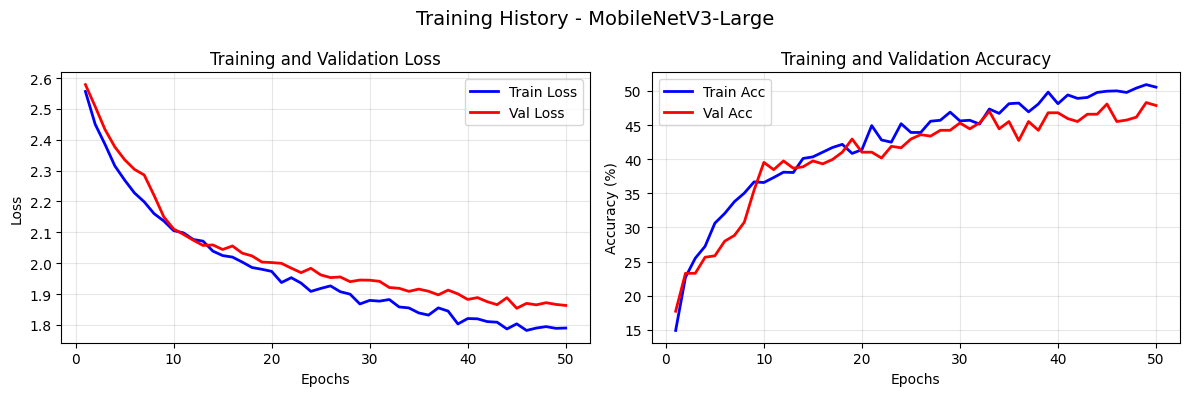


📊 Evaluating on test set...


Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]


✅ MobileNetV3-Large Results:
   Test Accuracy: 0.4423
   Test Precision: 0.4625
   Test Recall: 0.4423
   Test F1-Score: 0.4298
   Training Time: 16.98 minutes
   Best Validation Accuracy: 48.29% (Epoch 49)
   Total Epochs Trained: 50


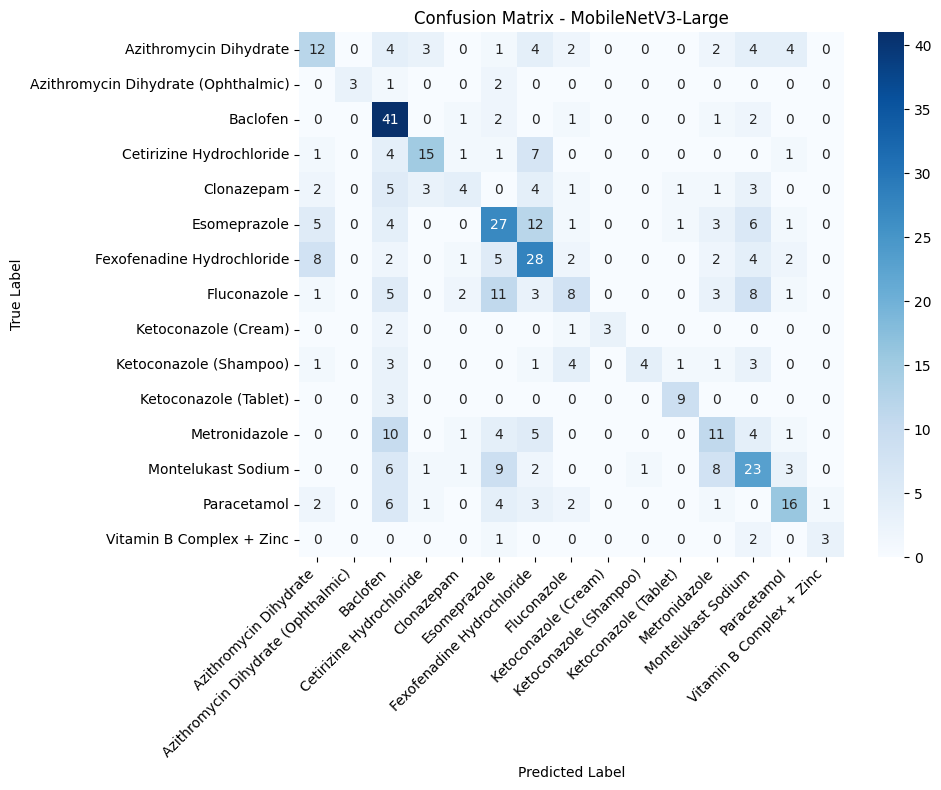

In [ ]:
# =========================================================
# MODEL 3: MobileNetV3-Large
# =========================================================
print("\n" + "="*60)
print("MODEL 3: MobileNetV3-Large")
print("="*60)

# Initialize model
model_mobilenet = models.mobilenet_v3_large(weights="IMAGENET1K_V1")
model_mobilenet = modify_mobilenet(model_mobilenet, num_classes)

# Freeze backbone, train only classifier
for param in model_mobilenet.parameters():
    param.requires_grad = False
for param in model_mobilenet.classifier.parameters():
    param.requires_grad = True

model_mobilenet = model_mobilenet.to(device)

# Count parameters
total_params = sum(p.numel() for p in model_mobilenet.parameters())
trainable_params = sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {trainable_params/total_params*100:.2f}%")

# Train and evaluate
mobilenet_results = train_and_evaluate_model(
    model=model_mobilenet,
    model_name="MobileNetV3-Large",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    num_classes=num_classes,
    class_names=class_names,
    epochs=100,
    lr=1e-4
)

all_results.append(mobilenet_results)

# Clear GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


MODEL 4: ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Total parameters: 23,538,767
Trainable parameters: 30,735
Trainable percentage: 0.13%

TRAINING: ResNet50

Starting training for 100 epochs (early stopping patience: 5)...


Epoch 1/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 1/100 Summary:
  Train Loss: 2.6348, Train Acc: 10.44%
  Val Loss: 2.5510, Val Acc: 14.32%
  LR: 1.00e-04
  💾 Saved best model (Epoch 1) with val_acc: 14.32%


...


Epoch 51/100 Summary:
  Train Loss: 2.2452, Train Acc: 28.89%
  Val Loss: 2.2455, Val Acc: 28.85%
  LR: 4.89e-05
EarlyStopping counter: 3 out of 5


Epoch 52/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 52/100 Summary:
  Train Loss: 2.2606, Train Acc: 27.15%
  Val Loss: 2.2397, Val Acc: 30.34%
  LR: 4.74e-05
  💾 Saved best model (Epoch 52) with val_acc: 30.34%
EarlyStopping counter: 4 out of 5


Epoch 53/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 53/100 Summary:
  Train Loss: 2.2445, Train Acc: 28.43%
  Val Loss: 2.2413, Val Acc: 30.98%
  LR: 4.58e-05
  💾 Saved best model (Epoch 53) with val_acc: 30.98%
EarlyStopping counter: 5 out of 5
⏹️  Early stopping triggered at epoch 53
Loaded best model from early stopping (epoch 53)


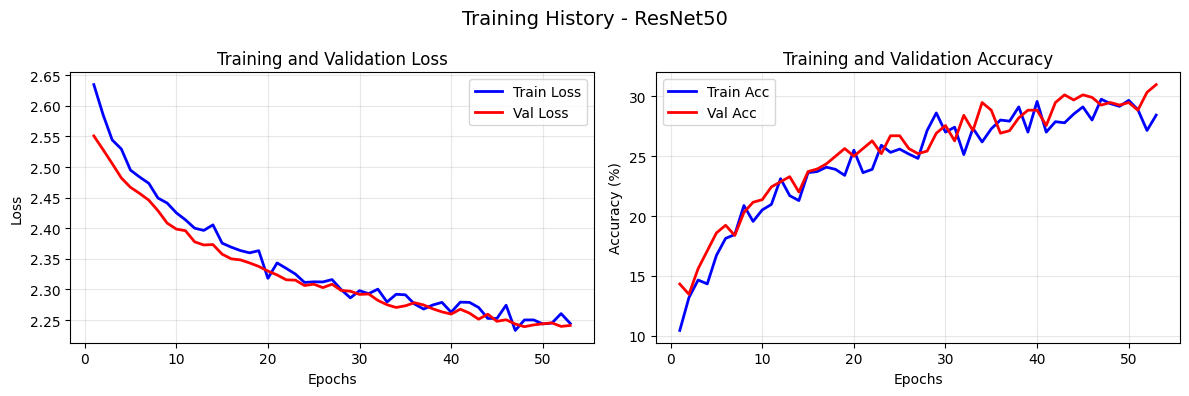


📊 Evaluating on test set...


Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]


✅ ResNet50 Results:
   Test Accuracy: 0.2521
   Test Precision: 0.2832
   Test Recall: 0.2521
   Test F1-Score: 0.2306
   Training Time: 19.32 minutes
   Best Validation Accuracy: 30.98% (Epoch 53)
   Total Epochs Trained: 53


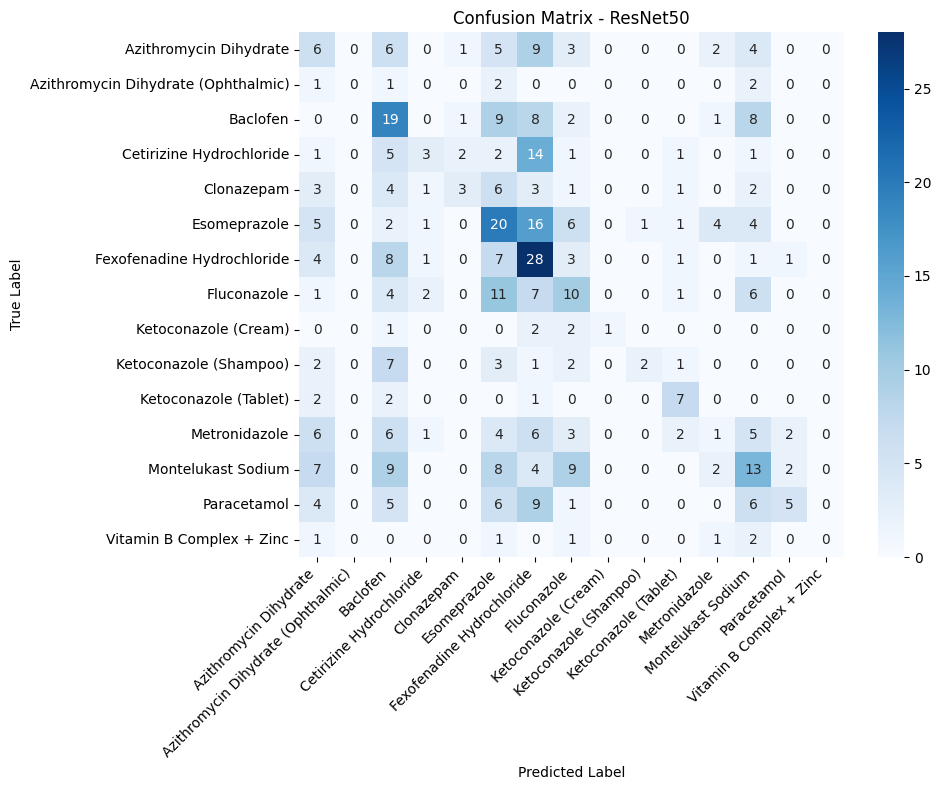

In [ ]:
# =========================================================
# MODEL 4: ResNet50
# =========================================================
print("\n" + "="*60)
print("MODEL 4: ResNet50")
print("="*60)

# Initialize model
model_resnet = models.resnet50(weights="IMAGENET1K_V1")
model_resnet = modify_resnet(model_resnet, num_classes)

# Freeze backbone, train only classifier
for param in model_resnet.parameters():
    param.requires_grad = False
for param in model_resnet.fc.parameters():
    param.requires_grad = True

model_resnet = model_resnet.to(device)

# Count parameters
total_params = sum(p.numel() for p in model_resnet.parameters())
trainable_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {trainable_params/total_params*100:.2f}%")

# Train and evaluate
resnet_results = train_and_evaluate_model(
    model=model_resnet,
    model_name="ResNet50",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    num_classes=num_classes,
    class_names=class_names,
    epochs=100,
    lr=1e-4
)

all_results.append(resnet_results)

# Clear GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


MODEL 5: Vision Transformer (ViT-B16)
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 50.8MB/s]


Total parameters: 85,810,191
Trainable parameters: 14,187,279
Trainable percentage: 16.53%

TRAINING: VisionTransformer-B16

Starting training for 100 epochs (early stopping patience: 5)...


Epoch 1/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 1/100 Summary:
  Train Loss: 2.4539, Train Acc: 19.46%
  Val Loss: 2.2558, Val Acc: 28.63%
  LR: 1.00e-04
  💾 Saved best model (Epoch 1) with val_acc: 28.63%


...


Epoch 39/100 Summary:
  Train Loss: 0.5979, Train Acc: 99.40%
  Val Loss: 0.9820, Val Acc: 85.26%
  LR: 6.73e-05
EarlyStopping counter: 3 out of 5


Epoch 40/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 40/100 Summary:
  Train Loss: 0.5999, Train Acc: 99.22%
  Val Loss: 0.9939, Val Acc: 84.19%
  LR: 6.58e-05
EarlyStopping counter: 4 out of 5


Epoch 41/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 41/100 Summary:
  Train Loss: 0.5973, Train Acc: 99.31%
  Val Loss: 0.9605, Val Acc: 84.19%
  LR: 6.43e-05
EarlyStopping counter: 5 out of 5
⏹️  Early stopping triggered at epoch 41
Loaded best model from early stopping (epoch 36)


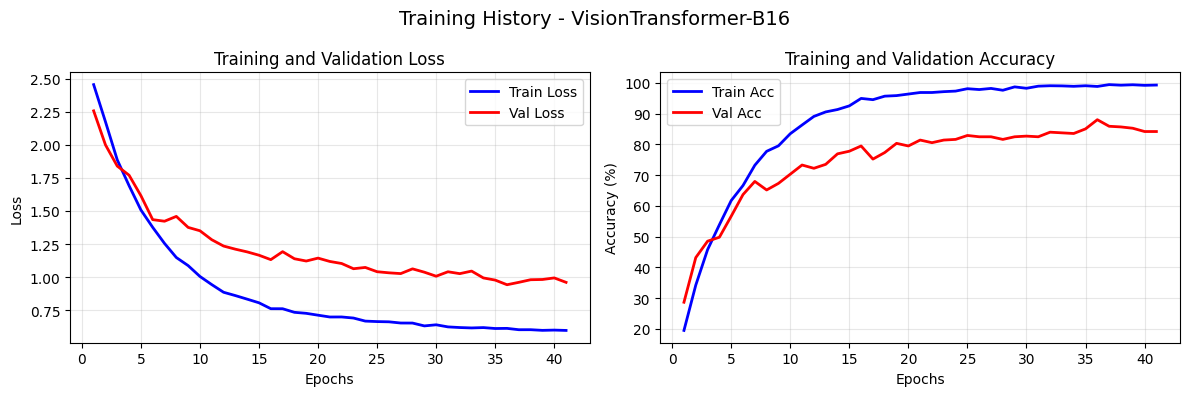


📊 Evaluating on test set...


Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]


✅ VisionTransformer-B16 Results:
   Test Accuracy: 0.8184
   Test Precision: 0.8218
   Test Recall: 0.8184
   Test F1-Score: 0.8181
   Training Time: 29.01 minutes
   Best Validation Accuracy: 88.03% (Epoch 36)
   Total Epochs Trained: 41


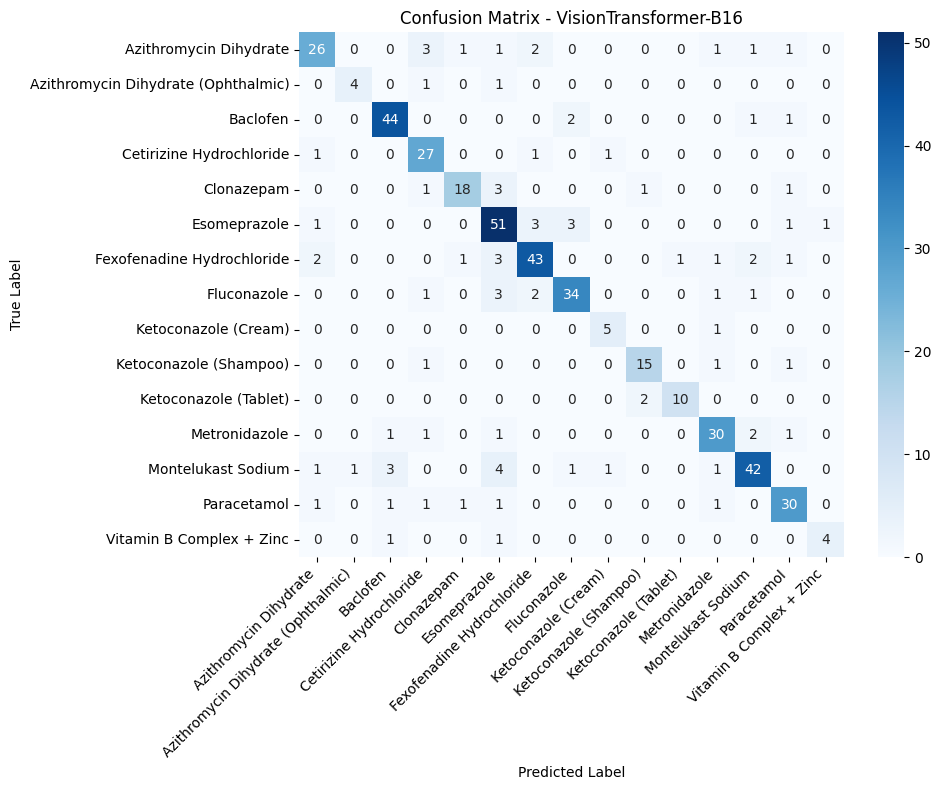

In [ ]:
# =========================================================
# MODEL 5: Vision Transformer (ViT-B16)
# =========================================================
print("\n" + "="*60)
print("MODEL 5: Vision Transformer (ViT-B16)")
print("="*60)

# Initialize model
model_vit = models.vit_b_16(weights="IMAGENET1K_V1")
model_vit = modify_vit(model_vit, num_classes)
model_vit = model_vit.to(device)

# Count parameters
total_params = sum(p.numel() for p in model_vit.parameters())
trainable_params = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {trainable_params/total_params*100:.2f}%")

# Train and evaluate
vit_results = train_and_evaluate_model(
    model=model_vit,
    model_name="VisionTransformer-B16",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    num_classes=num_classes,
    class_names=class_names,
    epochs=100,
    lr=1e-4
)

all_results.append(vit_results)

# Clear GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


MODEL 6: CNN-Transformer Hybrid
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Total parameters: 17,616,463
Trainable parameters: 6,439,951
Trainable percentage: 36.56%

TRAINING: CNN-Transformer Hybrid

Starting training for 100 epochs (early stopping patience: 5)...


Epoch 1/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 1/100 Summary:
  Train Loss: 2.5769, Train Acc: 13.28%
  Val Loss: 2.5068, Val Acc: 15.60%
  LR: 1.00e-04
  💾 Saved best model (Epoch 1) with val_acc: 15.60%


...


Epoch 40/100 Summary:
  Train Loss: 1.2927, Train Acc: 70.38%
  Val Loss: 1.7398, Val Acc: 53.85%
  LR: 6.58e-05
EarlyStopping counter: 3 out of 5


Epoch 41/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 41/100 Summary:
  Train Loss: 1.2746, Train Acc: 71.61%
  Val Loss: 1.6812, Val Acc: 56.20%
  LR: 6.43e-05
  💾 Saved best model (Epoch 41) with val_acc: 56.20%
EarlyStopping counter: 4 out of 5


Epoch 42/100:   0%|          | 0/69 [00:00<?, ?it/s]


Epoch 42/100 Summary:
  Train Loss: 1.2605, Train Acc: 72.66%
  Val Loss: 1.6852, Val Acc: 54.70%
  LR: 6.28e-05
EarlyStopping counter: 5 out of 5
⏹️  Early stopping triggered at epoch 42
Loaded best model from early stopping (epoch 41)


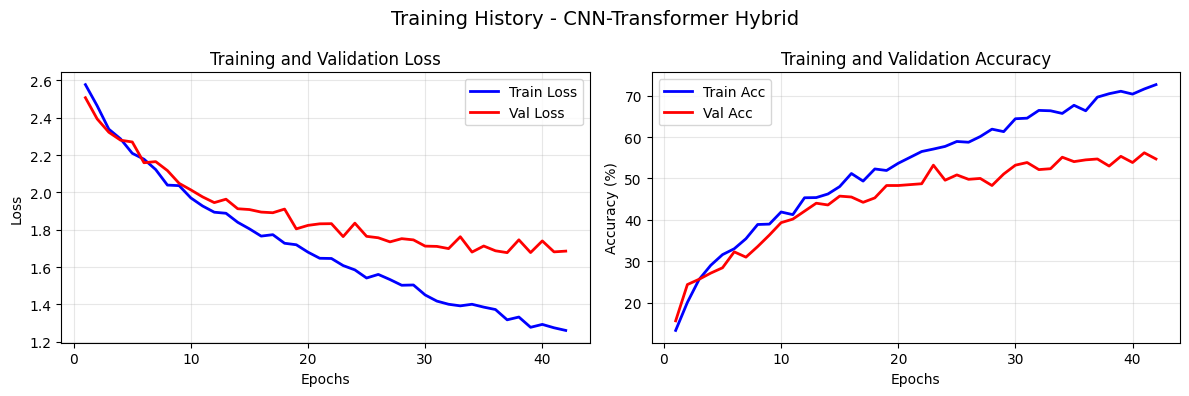


📊 Evaluating on test set...


Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]


✅ CNN-Transformer Hybrid Results:
   Test Accuracy: 0.5321
   Test Precision: 0.5576
   Test Recall: 0.5321
   Test F1-Score: 0.5290
   Training Time: 14.39 minutes
   Best Validation Accuracy: 56.20% (Epoch 41)
   Total Epochs Trained: 42


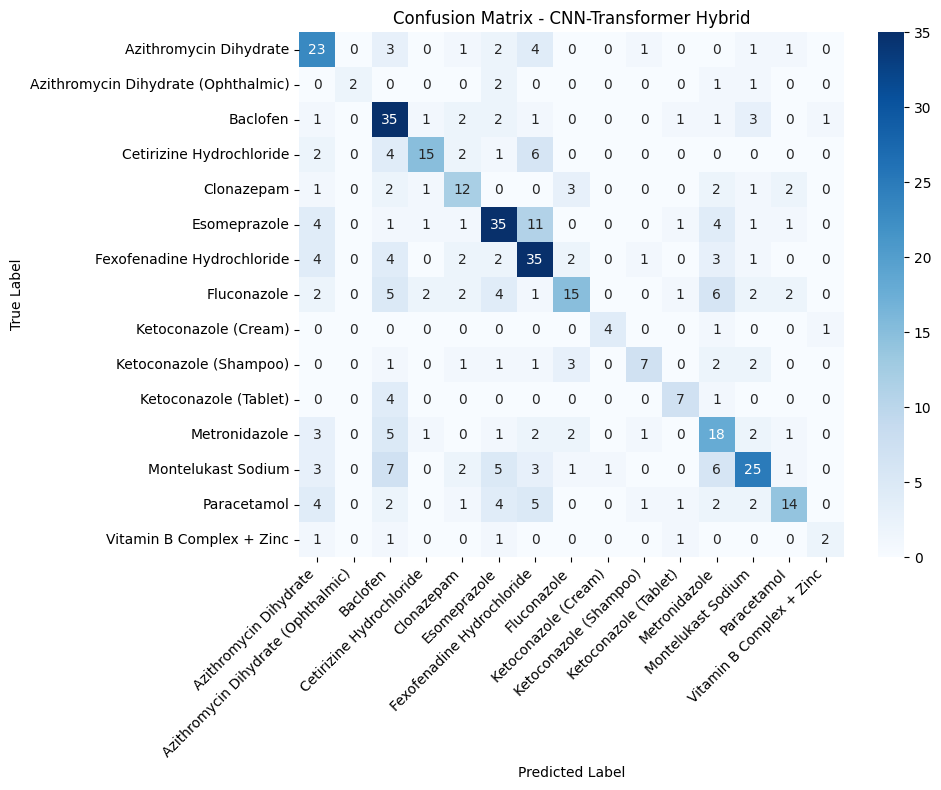

In [ ]:
# =========================================================
# MODEL 6: CNN-Transformer Hybrid
# =========================================================
print("\n" + "="*60)
print("MODEL 6: CNN-Transformer Hybrid")
print("="*60)

# Initialize model
model_hybrid = CNNTransformerHybrid(num_classes)
model_hybrid = modify_hybrid(model_hybrid, num_classes)
model_hybrid = model_hybrid.to(device)

# Count parameters
total_params = sum(p.numel() for p in model_hybrid.parameters())
trainable_params = sum(p.numel() for p in model_hybrid.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {trainable_params/total_params*100:.2f}%")

# Train and evaluate
hybrid_results = train_and_evaluate_model(
    model=model_hybrid,
    model_name="CNN-Transformer Hybrid",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    num_classes=num_classes,
    class_names=class_names,
    epochs=100,
    lr=1e-4
)

all_results.append(hybrid_results)

# Clear GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


FINAL MODEL COMPARISON

📊 COMPLETE RESULTS:
--------------------------------------------------------------------------------
                 Model  Accuracy  Precision   Recall  F1-score  Training Time (min)  Best Val Acc (%)  Best Epoch  Total Epochs
 VisionTransformer-B16  0.818376   0.821790 0.818376  0.818100            29.011328         88.034188          36            41
CNN-Transformer Hybrid  0.532051   0.557603 0.532051  0.528956            14.390852         56.196581          41            42
     MobileNetV3-Large  0.442308   0.462543 0.442308  0.429803            16.981780         48.290598          49            50
           DenseNet121  0.311966   0.306026 0.311966  0.291182            23.252569         32.905983          50            62
       EfficientNet-B3  0.297009   0.326822 0.297009  0.265975            27.533244         27.777778          48            56
              ResNet50  0.252137   0.283242 0.252137  0.230588            19.323243         30.982906     

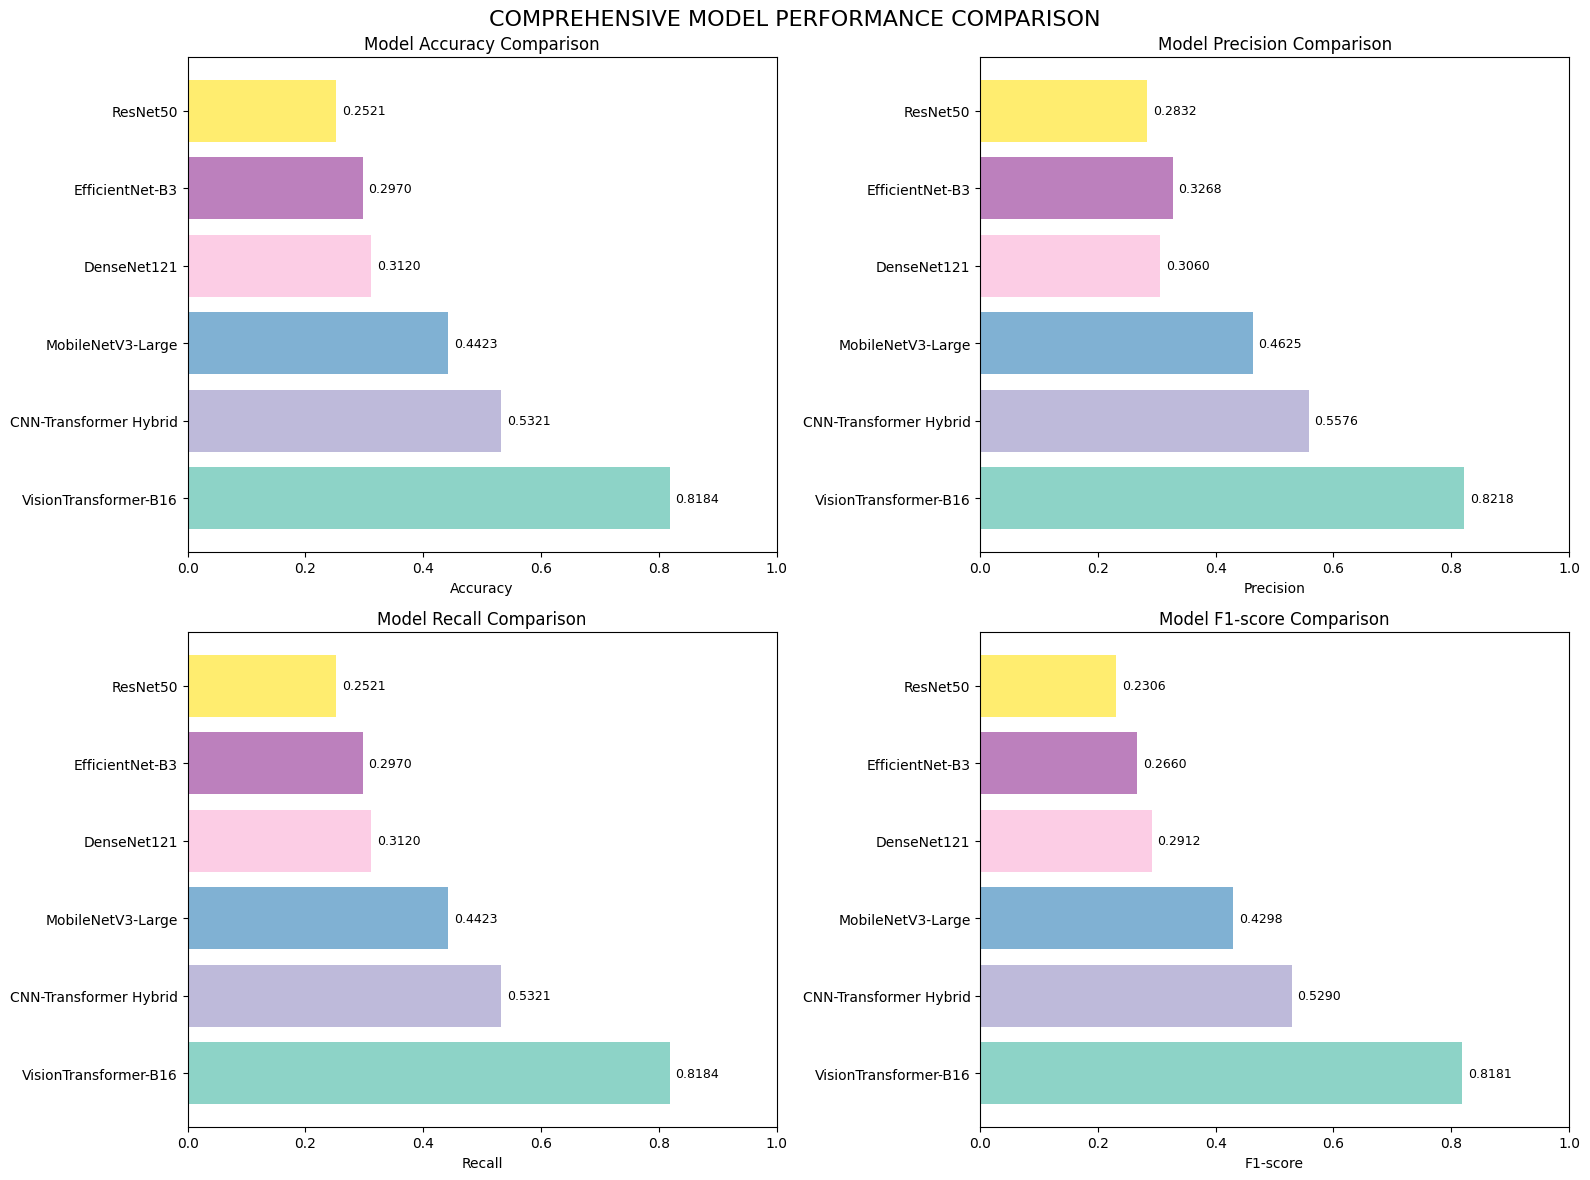

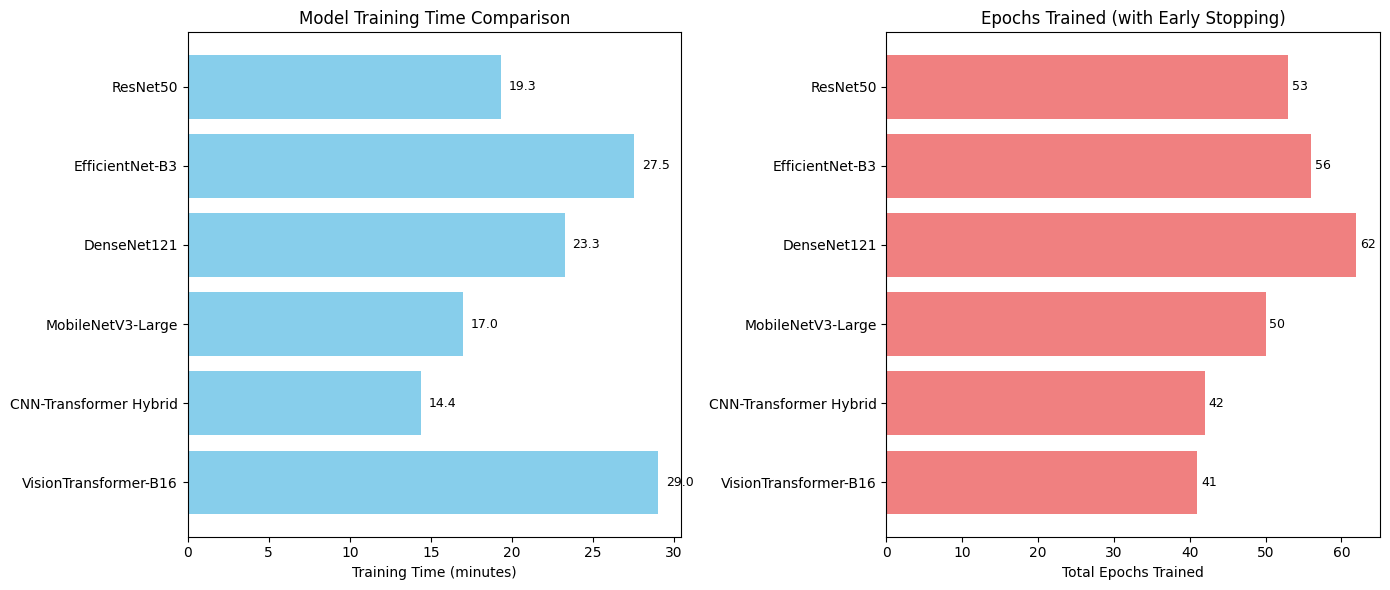


🏆 BEST PERFORMING MODEL
Model: VisionTransformer-B16
Accuracy: 0.8184
F1-Score: 0.8181
Precision: 0.8218
Recall: 0.8184
Training Time: 29.01 minutes
Best Validation Accuracy: 88.03%
Total Epochs Trained: 41


In [ ]:
# =========================================================
# MODEL COMPARISON AND RESULTS
# =========================================================
print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

# Create results dataframe
results_df = pd.DataFrame(all_results)

# Sort by accuracy
results_df = results_df.sort_values('Accuracy', ascending=False)

# Display full results
print("\n📊 COMPLETE RESULTS:")
print("-"*80)
print(results_df.to_string(index=False))
print("-"*80)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
colors = plt.cm.Set3(np.linspace(0, 1, len(results_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.barh(results_df['Model'], results_df[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'Model {metric} Comparison')
    ax.set_xlim([0, 1])

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
               f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.suptitle('COMPREHENSIVE MODEL PERFORMANCE COMPARISON', fontsize=16)
plt.tight_layout()
plt.show()

# Plot training time comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training time
axes[0].barh(results_df['Model'], results_df['Training Time (min)'], color='skyblue')
axes[0].set_xlabel('Training Time (minutes)')
axes[0].set_title('Model Training Time Comparison')
for i, (model, time_val) in enumerate(zip(results_df['Model'], results_df['Training Time (min)'])):
    axes[0].text(time_val + 0.5, i, f'{time_val:.1f}', va='center', fontsize=9)

# Epochs trained
axes[1].barh(results_df['Model'], results_df['Total Epochs'], color='lightcoral')
axes[1].set_xlabel('Total Epochs Trained')
axes[1].set_title('Epochs Trained (with Early Stopping)')
for i, (model, epochs) in enumerate(zip(results_df['Model'], results_df['Total Epochs'])):
    axes[1].text(epochs + 0.5, i, f'{epochs:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print best model
best_model = results_df.iloc[0]
print("\n" + "="*80)
print("🏆 BEST PERFORMING MODEL")
print("="*80)
print(f"Model: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")
print(f"F1-Score: {best_model['F1-score']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall: {best_model['Recall']:.4f}")
print(f"Training Time: {best_model['Training Time (min)']:.2f} minutes")
print(f"Best Validation Accuracy: {best_model['Best Val Acc (%)']:.2f}%")
print(f"Total Epochs Trained: {best_model['Total Epochs']}")
print("="*80)

In [ ]:
# =========================================================
# SAVE RESULTS
# =========================================================
print("\n💾 SAVING RESULTS...")

# Save results to CSV
results_df.to_csv("all_models_results.csv", index=False)
print("✅ Results saved to 'all_models_results.csv'")

# Save detailed results
detailed_results = {
    "training_config": {
        "batch_size": BATCH_SIZE,
        "max_epochs": 100,
        "learning_rate": 1e-4,
        "num_classes": num_classes,
        "min_samples_per_class": MIN_SAMPLES_PER_CLASS,
        "total_samples": len(df_filtered),
        "train_samples": len(train_df),
        "val_samples": len(val_df),
        "test_samples": len(test_df),
        "device": str(device)
    },
    "model_results": results_df.to_dict('records')
}

with open("detailed_all_models_results.json", "w") as f:
    json.dump(detailed_results, f, indent=2)
print("✅ Detailed results saved to 'detailed_all_models_results.json'")

print("\n🎉 PROJECT COMPLETED SUCCESSFULLY!")


💾 SAVING RESULTS...
✅ Results saved to 'all_models_results.csv'
✅ Detailed results saved to 'detailed_all_models_results.json'

🎉 PROJECT COMPLETED SUCCESSFULLY!
